# Reconstructing the Yield Curve with a CIR Short-Rate Model

This notebook builds a complete modelling workflow for the project: the yield data is cleaned, a CIR short-rate process is calibrated, the full curve is reconstructed from the observed 3-month rate, and CIR-based improvements are compared using out-of-sample pooled R2.


## Project Frame

For every test date, the model is allowed to read only the 3-month yield. The remaining maturities are rebuilt from that single input, so the notebook keeps the short-rate column, tenor map, and target score visible from the start.


In [1]:
import math
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution, minimize
from scipy.stats import ncx2

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT = SimpleNamespace(
    calendar_step=1 / 252,
    rate_floor=1e-6,
    short_col="ZC025YR",
    required_r2=0.85,
    seed=42,
)

TENOR_YEAR = pd.Series(
    {
        "ZC025YR": 0.25,
        "ZC050YR": 0.50,
        "ZC075YR": 0.75,
        "ZC100YR": 1.00,
        "ZC200YR": 2.00,
        "ZC500YR": 5.00,
        "ZC1000YR": 10.00,
        "ZC2000YR": 20.00,
        "ZC3000YR": 30.00,
    },
    name="years",
)

SHORT_RATE_COL = PROJECT.short_col
TARGET_TENORS = TENOR_YEAR.index.drop(SHORT_RATE_COL).tolist()
BUSINESS_DAY = PROJECT.calendar_step
RATE_FLOOR = PROJECT.rate_floor
MINIMUM_R2 = PROJECT.required_r2
RANDOM_SEED = PROJECT.seed

np.random.seed(PROJECT.seed)
display(TENOR_YEAR.to_frame().T)
print(f"Only test-time input used for prediction: {PROJECT.short_col}")


,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
years,0.25,0.5,0.75,1.0,2.0,5.0,10.0,20.0,30.0


Only test-time input used for prediction: ZC025YR


## Getting the Yield Panels Ready

The raw files can contain formatting issues, missing observations, duplicate dates, and sharp non-trading-day jumps. I first sort the dates, interpolate missing yields through time, and then cap unusual daily changes using a rolling median and MAD filter. Outliers are detected on changes, not levels, because an interest-rate level can stay high or low for a long time without being an error.


In [2]:
def candidate_locations(filename):
    here = Path.cwd()
    for folder in [here, here / "data", here.parent / "data"]:
        yield folder / filename


def first_existing_csv(filename):
    for path in candidate_locations(filename):
        if path.exists():
            return path
    searched = [str(path) for path in candidate_locations(filename)]
    raise FileNotFoundError(f"{filename} was not found. Checked: {searched}")


def cap_extreme_day_changes(curve_column):
    level = pd.to_numeric(curve_column, errors="coerce").astype(float)
    move = level.diff()
    local_median = move.rolling(63, min_periods=20).median()
    local_mad = (move - local_median).abs().rolling(63, min_periods=20).median()
    local_scale = (1.4826 * local_mad).replace(0, np.nan)

    jump_mask = (((move - local_median) / local_scale).abs() > 8) & (move.abs() > 0.01)
    jump_mask = jump_mask.fillna(False)
    bounded_move = move.mask(
        jump_mask,
        move.clip(lower=local_median - 8 * local_scale, upper=local_median + 8 * local_scale),
    )

    repaired = level.to_numpy(copy=True)
    bounded_arr = bounded_move.to_numpy()
    jump_arr = jump_mask.to_numpy()
    for idx in range(1, len(repaired)):
        if jump_arr[idx] and np.isfinite(bounded_arr[idx]):
            repaired[idx] = repaired[idx - 1] + bounded_arr[idx]
    return pd.Series(np.maximum(repaired, PROJECT.rate_floor), index=curve_column.index), int(jump_mask.sum())


def prepare_curve_file(filename):
    path = first_existing_csv(filename)
    raw = pd.read_csv(path)
    raw.columns = raw.columns.str.strip()

    before_rows = len(raw)
    raw["Date"] = pd.to_datetime(raw["Date"], errors="coerce")
    invalid_dates = int(raw["Date"].isna().sum())
    raw = raw.dropna(subset=["Date"]).sort_values("Date")
    duplicate_dates = int(raw.duplicated("Date").sum())
    raw = raw.drop_duplicates("Date", keep="first").set_index("Date")

    curve_columns = [name for name in TENOR_YEAR.index if name in raw.columns]
    raw[curve_columns] = raw[curve_columns].apply(pd.to_numeric, errors="coerce")
    missing_before = int(raw[curve_columns].isna().sum().sum())
    raw[curve_columns] = raw[curve_columns].interpolate(method="time").ffill().bfill()
    missing_after = int(raw[curve_columns].isna().sum().sum())

    capped = 0
    for column in curve_columns:
        raw[column], count = cap_extreme_day_changes(raw[column])
        capped += count

    clean = raw.reset_index()
    audit = {
        "file": path.name,
        "rows_before": before_rows,
        "rows_after": len(clean),
        "invalid_dates": invalid_dates,
        "duplicate_dates": duplicate_dates,
        "missing_before": missing_before,
        "missing_after": missing_after,
        "capped_daily_moves": capped,
    }
    return clean, audit


panels = {}
audits = []
for label, filename in {"train": "train_data.csv", "test": "test_data.csv", "test_3m": "test_data_3M.csv"}.items():
    panels[label], audit = prepare_curve_file(filename)
    audits.append({"dataset": label, **audit})

train_full = panels["train"]
test_full = panels["test"]
test_3m = panels["test_3m"]

assert list(test_3m.columns) == ["Date", PROJECT.short_col], "Prediction input must contain only Date and 3M."
display(pd.DataFrame(audits))
print("Prepared shapes:", {name: frame.shape for name, frame in panels.items()})


,dataset,file,rows_before,rows_after,invalid_dates,duplicate_dates,missing_before,missing_after,capped_daily_moves
0,train,train_data.csv,1976,1976,0,0,0,0,0
1,test,test_data.csv,495,495,0,0,0,0,0
2,test_3m,test_data_3M.csv,495,495,0,0,0,0,0


Prepared shapes: {'train': (1976, 10), 'test': (495, 6), 'test_3m': (495, 2)}


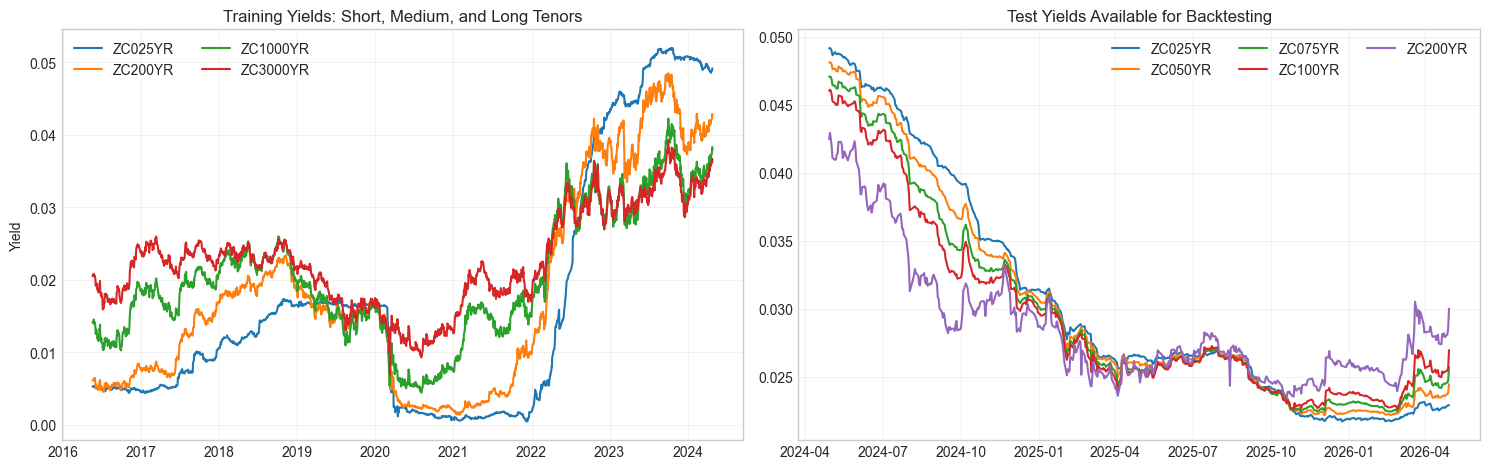

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
key_training_tenors = [SHORT_RATE_COL, "ZC200YR", "ZC1000YR", "ZC3000YR"]

for tenor in key_training_tenors:
    axes[0].plot(train_full["Date"], train_full[tenor], linewidth=1.5, label=tenor)
axes[0].set_title("Training Yields: Short, Medium, and Long Tenors")
axes[0].set_ylabel("Yield")
axes[0].legend(frameon=False, ncol=2)

for tenor in [c for c in test_full.columns if c != "Date"]:
    axes[1].plot(test_full["Date"], test_full[tenor], linewidth=1.5, label=tenor)
axes[1].set_title("Test Yields Available for Backtesting")
axes[1].legend(frameon=False, ncol=3)

for ax in axes:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## CIR Building Blocks

The CIR model assumes mean reversion with volatility proportional to the square root of the short rate. I estimate the short-rate dynamics in two steps. OLS gives a stable starting point, and exact transition MLE refines the parameters using the known non-central chi-square transition density of the CIR process.


In [4]:
@dataclass(frozen=True)
class CIRTheta:
    kappa: float
    theta: float
    sigma: float

    @property
    def feller_margin(self):
        return 2 * self.kappa * self.theta - self.sigma**2


def floored(values):
    return np.maximum(np.asarray(values, dtype=float), PROJECT.rate_floor)


def affine_terms(theta_pack, maturity_grid):
    tau = np.asarray(maturity_grid, dtype=float).reshape(1, -1)
    kappa = max(theta_pack.kappa, 1e-10)
    theta = max(theta_pack.theta, PROJECT.rate_floor)
    sigma = max(theta_pack.sigma, 1e-10)

    gamma = math.sqrt(kappa * kappa + 2 * sigma * sigma)
    growth = np.exp(np.clip(gamma * tau, -700, 700))
    normalizer = (gamma + kappa) * (growth - 1) + 2 * gamma
    b = 2 * (growth - 1) / normalizer
    log_a = (2 * kappa * theta / sigma**2) * (
        math.log(2 * gamma) + 0.5 * (kappa + gamma) * tau - np.log(normalizer)
    )
    return log_a, b


def curve_from_three_month(short_rate_values, theta_pack, tenor_list=TARGET_TENORS):
    r = floored(short_rate_values).reshape(-1, 1)
    years = TENOR_YEAR.loc[tenor_list].to_numpy(float)
    log_a, b = affine_terms(theta_pack, years)
    return np.maximum((b * r - log_a) / years.reshape(1, -1), PROJECT.rate_floor)


def ar1_seed(short_rate_values):
    path = floored(short_rate_values)
    today, tomorrow = path[:-1], path[1:]
    intercept, slope = np.linalg.lstsq(np.c_[np.ones_like(today), today], tomorrow, rcond=None)[0]
    slope = float(np.clip(slope, 1e-8, 0.99999999))

    kappa = -math.log(slope) / PROJECT.calendar_step
    theta = max(float(intercept / (1 - slope)), PROJECT.rate_floor)
    innovation = tomorrow - (intercept + slope * today)
    sigma = np.std(innovation / np.sqrt(np.maximum(today, PROJECT.rate_floor)), ddof=1) / math.sqrt(PROJECT.calendar_step)
    return CIRTheta(float(kappa), float(theta), max(float(sigma), 1e-10))


def exact_transition_loss(candidate, short_rate_values):
    kappa, theta, sigma = np.asarray(candidate, dtype=float)
    if min(kappa, theta, sigma) <= 0:
        return 1e15

    path = floored(short_rate_values)
    today, tomorrow = path[:-1], path[1:]
    decay = math.exp(-kappa * PROJECT.calendar_step)
    gap = 1 - decay
    if gap <= 0:
        return 1e15

    scale = sigma**2 * gap / (4 * kappa)
    degrees = 4 * kappa * theta / sigma**2
    noncentral = 4 * kappa * decay * today / (sigma**2 * gap)
    if scale <= 0 or degrees <= 0 or not np.isfinite(scale):
        return 1e15

    log_pdf = ncx2.logpdf(tomorrow / scale, degrees, noncentral) - math.log(scale)
    return -float(np.sum(log_pdf)) if np.all(np.isfinite(log_pdf)) else 1e15


def mle_refinement(short_rate_values, starting_theta=None):
    guess = starting_theta or ar1_seed(short_rate_values)
    x0 = np.clip([guess.kappa, guess.theta, guess.sigma], [1e-8, PROJECT.rate_floor, 1e-8], [1000, 100000, 10])
    fit = minimize(
        lambda row: exact_transition_loss(row, short_rate_values),
        x0,
        method="Nelder-Mead",
        options={"maxiter": 5000, "xatol": 1e-10, "fatol": 1e-8, "disp": False},
    )
    kappa, theta, sigma = np.clip(fit.x if np.isfinite(fit.fun) else x0, [1e-10, PROJECT.rate_floor, 1e-10], [np.inf, np.inf, np.inf])
    return CIRTheta(float(kappa), float(theta), float(sigma)), float(fit.fun), bool(fit.success)


def parameter_card(label, theta_pack, **extra):
    row = {"kappa": theta_pack.kappa, "theta": theta_pack.theta, "sigma": theta_pack.sigma, "feller_margin": theta_pack.feller_margin, **extra}
    print(f"\n{label}")
    display(pd.DataFrame([row]).T.rename(columns={0: "value"}))


In [5]:
ols_parameters = ar1_seed(train_full[SHORT_RATE_COL])
mle_parameters, mle_loss, mle_success = mle_refinement(train_full[SHORT_RATE_COL], ols_parameters)

parameter_card("OLS starting parameters", ols_parameters)
parameter_card("Exact MLE short-rate parameters", mle_parameters, negative_log_likelihood=mle_loss, success=mle_success)

long_end_check = curve_from_three_month([train_full[SHORT_RATE_COL].iloc[-1]], mle_parameters, ["ZC2000YR", "ZC3000YR"])
print("Long-maturity numerical check:", long_end_check.ravel())



OLS starting parameters


,value
kappa,0.000003
theta,975.276599
sigma,0.041360
feller_margin,0.003205



Exact MLE short-rate parameters


,value
kappa,0.0
theta,39861.154756
sigma,0.042576
feller_margin,0.002286
negative_log_likelihood,-13558.410857
success,True


Long-maturity numerical check: [0.06334044 0.06637118]


### What the Fitted Short Rate Can Do

The simulation below is not used for scoring. It is included to show what the fitted CIR process implies for possible one-year short-rate paths. The paths mean-revert toward theta, while the square-root volatility keeps the process close to positive territory.


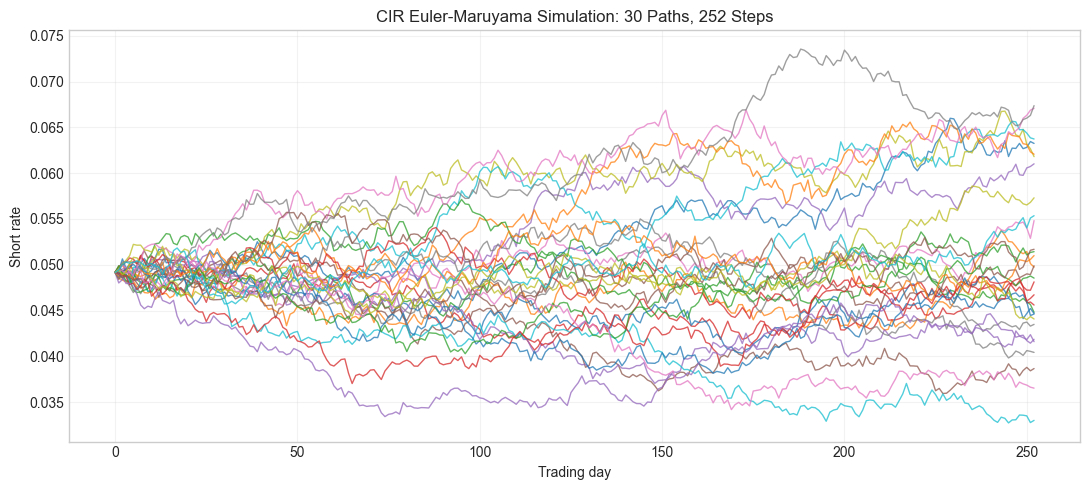

In [6]:
def simulate_cir_paths(start_rate, kappa, theta, sigma, n_paths=30, n_steps=252, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    paths = np.zeros((n_steps + 1, n_paths))
    paths[0] = max(float(start_rate), RATE_FLOOR)
    for step in range(n_steps):
        current = np.clip(paths[step], RATE_FLOOR, None)
        drift = kappa * (theta - current) * BUSINESS_DAY
        diffusion = sigma * np.sqrt(current) * math.sqrt(BUSINESS_DAY) * rng.normal(size=n_paths)
        paths[step + 1] = np.clip(current + drift + diffusion, RATE_FLOOR, None)
    return paths


paths = simulate_cir_paths(
    train_full[SHORT_RATE_COL].iloc[-1],
    mle_parameters.kappa,
    mle_parameters.theta,
    mle_parameters.sigma,
)

plt.figure(figsize=(11, 5))
plt.plot(paths, linewidth=1, alpha=0.75)
plt.title("CIR Euler-Maruyama Simulation: 30 Paths, 252 Steps")
plt.xlabel("Trading day")
plt.ylabel("Short rate")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Backtest Scorecard

The official number is a pooled R2 over every labeled target maturity in the test file. I also print RMSE and bias by tenor because they explain where the model is gaining or losing accuracy.


In [7]:
def aligned_error_frame(actual_frame, predicted_frame, tenor):
    return pd.DataFrame(
        {
            "actual": pd.to_numeric(actual_frame[tenor], errors="coerce"),
            "predicted": pd.to_numeric(predicted_frame[tenor], errors="coerce"),
        }
    ).dropna()


def evaluate_reconstruction(actual_frame, predicted_frame, title):
    tenor_stats = []
    stacked_actual = []
    stacked_predicted = []

    for tenor in TARGET_TENORS:
        if tenor not in actual_frame.columns or tenor not in predicted_frame.columns:
            continue
        pair = aligned_error_frame(actual_frame, predicted_frame, tenor)
        actual = pair["actual"].to_numpy(float)
        predicted = pair["predicted"].to_numpy(float)
        error = actual - predicted
        total_variation = np.sum((actual - actual.mean()) ** 2)
        tenor_stats.append(
            {
                "tenor": tenor,
                "r2": np.nan if total_variation <= 0 else 1 - np.sum(error**2) / total_variation,
                "rmse_bps": np.sqrt(np.mean(error**2)) * 10000,
                "bias_bps": np.mean(predicted - actual) * 10000,
            }
        )
        stacked_actual.append(actual)
        stacked_predicted.append(predicted)

    pooled_actual = np.concatenate(stacked_actual)
    pooled_predicted = np.concatenate(stacked_predicted)
    pooled_error = pooled_actual - pooled_predicted
    pooled_r2 = float(1 - np.sum(pooled_error**2) / np.sum((pooled_actual - pooled_actual.mean()) ** 2))
    table = pd.DataFrame(tenor_stats)
    table.loc[len(table)] = {
        "tenor": "POOLED",
        "r2": pooled_r2,
        "rmse_bps": np.sqrt(np.mean(pooled_error**2)) * 10000,
        "bias_bps": np.mean(pooled_predicted - pooled_actual) * 10000,
    }

    print(f"\n{title}\n" + "-" * len(title))
    print(table.to_string(index=False, float_format=lambda x: f"{x: .5f}"))
    return table, pooled_r2


## Benchmark: Plain CIR

The benchmark is the direct CIR implementation. It learns kappa, theta, and sigma from the training 3-month series and then applies the affine CIR yield formula to every target maturity. This asks one short-rate factor to explain the full curve.


In [8]:
def short_input_only(frame):
    if set(frame.columns) != {"Date", PROJECT.short_col}:
        raise AssertionError("Prediction must use only Date and the same-day 3M yield.")


def prediction_table(short_rate_frame, theta_pack, tenor_list=TARGET_TENORS):
    short_input_only(short_rate_frame)
    values = curve_from_three_month(short_rate_frame[PROJECT.short_col], theta_pack, tenor_list)
    out = pd.DataFrame(values, columns=tenor_list)
    out.insert(0, "Date", pd.to_datetime(short_rate_frame["Date"]).to_numpy())
    return out


base_theta, base_loss, base_success = mle_refinement(train_full[PROJECT.short_col], ar1_seed(train_full[PROJECT.short_col]))
parameter_card("Base CIR calibrated parameters", base_theta, negative_log_likelihood=base_loss, success=base_success)

base_prediction = prediction_table(test_3m, base_theta)
base_metrics, base_r2 = evaluate_reconstruction(test_full, base_prediction, "Model A: Base CIR")



Base CIR calibrated parameters


,value
kappa,0.0
theta,39861.154756
sigma,0.042576
feller_margin,0.002286
negative_log_likelihood,-13558.410857
success,True



Model A: Base CIR
-----------------
  tenor       r2  rmse_bps  bias_bps
ZC050YR  0.97704  11.94225   8.83896
ZC075YR  0.90339  22.44156  15.62595
ZC100YR  0.76315  32.02826  21.20592
ZC200YR -0.61824  59.49677  36.83229
 POOLED  0.71096  36.09680  20.62578


## First Improvement: A Median Shift Overlay

CIR++ is a simple way to repair a one-factor curve. I first fit an affine CIR curve, then learn the median training residual for each maturity. At test time that fixed tenor-wise correction is added after the curve is generated from the 3-month rate.


In [9]:
def curve_fit_objective(row, short_rates, training_frame, fit_tenors, curve_weight=1e7, feller_penalty=500.0):
    row = np.asarray(row, dtype=float)
    if np.any(row <= 0) or not np.all(np.isfinite(row)):
        return 1e15

    nll = exact_transition_loss(row, short_rates)
    if not np.isfinite(nll) or nll >= 1e14:
        return 1e15

    theta_pack = CIRTheta(*map(float, row))
    observed_curve = training_frame[fit_tenors].to_numpy(float)
    reconstructed_curve = curve_from_three_month(short_rates, theta_pack, fit_tenors)
    reconstruction_rmse = np.sqrt(np.mean((observed_curve - reconstructed_curve) ** 2))
    feller_gap = max(0.0, theta_pack.sigma**2 - 2 * theta_pack.kappa * theta_pack.theta)
    return float(nll + curve_weight * reconstruction_rmse + feller_penalty * feller_gap)


def calibrate_for_curve_reconstruction(training_frame, curve_weight=1e7, maxiter=60, popsize=12, seed=RANDOM_SEED):
    short_rates = training_frame[PROJECT.short_col].to_numpy(float)
    fit_tenors = [tenor for tenor in TARGET_TENORS if tenor in training_frame.columns]
    short_mean = float(np.mean(short_rates))
    short_std = float(np.std(short_rates))
    short_max = float(np.max(short_rates))
    bounds = [
        (1e-4, 4.0),
        (max(PROJECT.rate_floor, 0.25 * short_mean), max(0.25, 4.0 * short_max)),
        (1e-4, max(0.5, 8.0 * max(short_std, 1e-3))),
    ]

    objective = lambda candidate: curve_fit_objective(candidate, short_rates, training_frame, fit_tenors, curve_weight=curve_weight)
    broad = differential_evolution(objective, bounds=bounds, seed=seed, maxiter=maxiter, popsize=popsize, polish=False, tol=1e-7, workers=1)
    final = minimize(objective, broad.x, method="L-BFGS-B", bounds=bounds, options={"maxiter": 1000})
    theta_pack = CIRTheta(*map(float, final.x))
    return theta_pack, float(final.fun), bool(final.success), fit_tenors


def fit_cirpp_shift(training_frame, backbone_theta):
    fitted_train = prediction_table(training_frame[["Date", PROJECT.short_col]], backbone_theta)
    residuals = training_frame[TARGET_TENORS].to_numpy(float) - fitted_train[TARGET_TENORS].to_numpy(float)
    return pd.Series(np.median(residuals, axis=0), index=TARGET_TENORS, name="median_shift")


curve_backbone_theta, curve_backbone_objective, curve_backbone_success, fitted_tenors = calibrate_for_curve_reconstruction(train_full)
parameter_card("Curve-aware backbone used for CIR++", curve_backbone_theta, objective=curve_backbone_objective, success=curve_backbone_success)

cirpp_shift = fit_cirpp_shift(train_full, curve_backbone_theta)
print("\nMedian deterministic shifts used in CIR++")
print(cirpp_shift.to_string(float_format=lambda x: f"{x: .8f}"))

cirpp_raw = prediction_table(test_3m, curve_backbone_theta)
cirpp_prediction = cirpp_raw.copy()
cirpp_prediction[TARGET_TENORS] = np.maximum(cirpp_raw[TARGET_TENORS].to_numpy(float) + cirpp_shift.to_numpy(), PROJECT.rate_floor)
cirpp_metrics, cirpp_r2 = evaluate_reconstruction(test_full, cirpp_prediction, "Model B: CIR++ Median Shift")



Curve-aware backbone used for CIR++


,value
kappa,0.163375
theta,0.024978
sigma,0.041813
feller_margin,0.006413
objective,25861.964834
success,True



Median deterministic shifts used in CIR++
ZC050YR     0.00048021
ZC075YR     0.00050771
ZC100YR     0.00044532
ZC200YR    -0.00110416
ZC500YR    -0.00139049
ZC1000YR   -0.00046965
ZC2000YR    0.00154573
ZC3000YR    0.00086933

Model B: CIR++ Median Shift
---------------------------
  tenor       r2  rmse_bps  bias_bps
ZC050YR  0.98816   8.57538   6.35735
ZC075YR  0.95251  15.73375   9.82416
ZC100YR  0.88985  21.84185  11.21625
ZC200YR  0.41110  35.89172  -2.59278
 POOLED  0.88429  22.83840   6.20124


## Main Candidate: Curve-Aware CIR Calibration

The final extension keeps the same affine CIR yield formula, but changes the calibration target. Instead of fitting only the 3-month transition density, the objective combines exact short-rate likelihood with training-curve reconstruction error. This is still a CIR model.


In [10]:
best_theta, best_objective, best_success, fitted_tenors = calibrate_for_curve_reconstruction(train_full)
parameter_card("Curve-aware affine CIR parameters", best_theta, objective=best_objective, success=best_success)
print("Training tenors used in curve-aware objective:", fitted_tenors)

best_prediction = prediction_table(test_3m, best_theta)
best_metrics, best_r2 = evaluate_reconstruction(test_full, best_prediction, "Model C: Curve-Aware Affine CIR")



Curve-aware affine CIR parameters


,value
kappa,0.163375
theta,0.024978
sigma,0.041813
feller_margin,0.006413
objective,25861.964834
success,True


Training tenors used in curve-aware objective: ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']

Model C: Curve-Aware Affine CIR
-------------------------------
  tenor       r2  rmse_bps  bias_bps
ZC050YR  0.99428   5.96156   1.55527
ZC075YR  0.96670  13.17464   4.74702
ZC100YR  0.90834  19.92489   6.76305
ZC200YR  0.38154  36.78145   8.44881
 POOLED  0.89136  22.13023   5.37854


## Diagnostics Worth Looking At

I keep the plots focused on the parts that explain the model: out-of-sample fit by important maturities, error size by tenor, full curve snapshots, and the final model ranking.


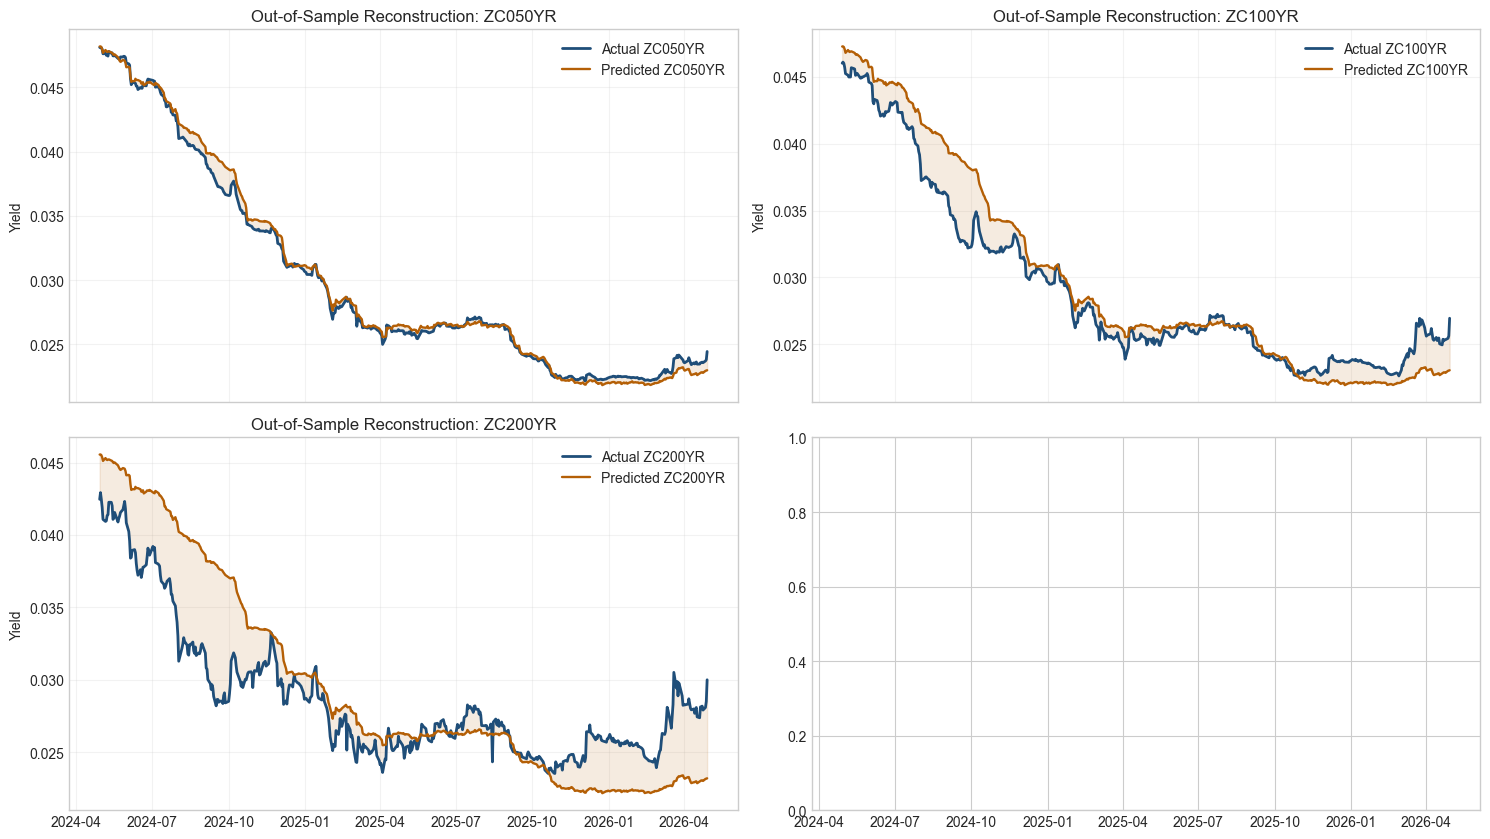

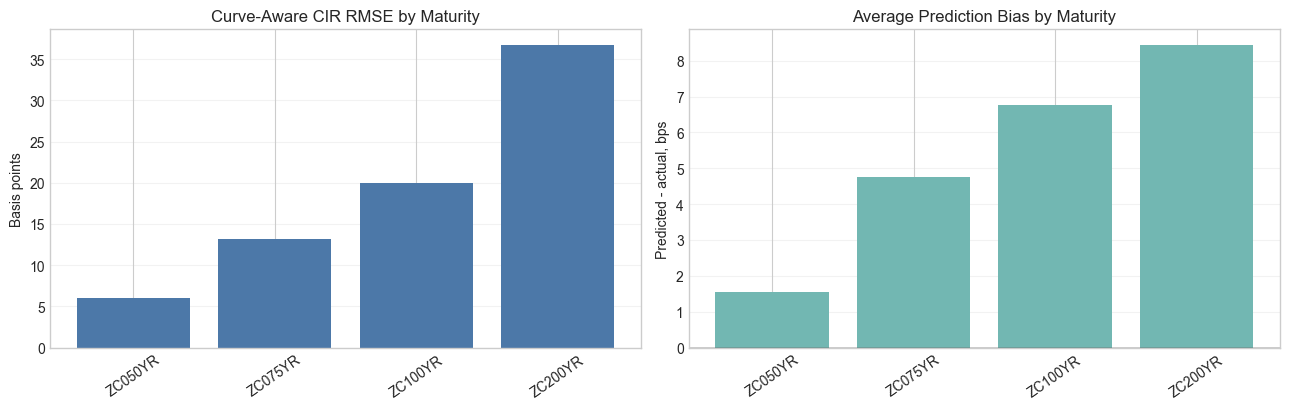

In [11]:
important_tenors = [tenor for tenor in ["ZC050YR", "ZC100YR", "ZC200YR", "ZC1000YR"] if tenor in test_full.columns]

fig, axes = plt.subplots(2, 2, figsize=(15, 8.5), sharex=True)
for ax, tenor in zip(axes.ravel(), important_tenors):
    ax.plot(test_full["Date"], test_full[tenor], label=f"Actual {tenor}", linewidth=2.0, color="#1f4e79")
    ax.plot(best_prediction["Date"], best_prediction[tenor], label=f"Predicted {tenor}", linewidth=1.7, color="#b45f06")
    ax.fill_between(
        test_full["Date"],
        test_full[tenor].to_numpy(float),
        best_prediction[tenor].to_numpy(float),
        color="#b45f06",
        alpha=0.12,
    )
    ax.set_title(f"Out-of-Sample Reconstruction: {tenor}")
    ax.set_ylabel("Yield")
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

plot_metrics = best_metrics[best_metrics["tenor"] != "POOLED"].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar(plot_metrics["tenor"], plot_metrics["rmse_bps"], color="#4c78a8")
axes[0].set_title("Curve-Aware CIR RMSE by Maturity")
axes[0].set_ylabel("Basis points")
axes[0].tick_params(axis="x", rotation=35)

axes[1].bar(plot_metrics["tenor"], plot_metrics["bias_bps"], color="#72b7b2")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Average Prediction Bias by Maturity")
axes[1].set_ylabel("Predicted - actual, bps")
axes[1].tick_params(axis="x", rotation=35)

for ax in axes:
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


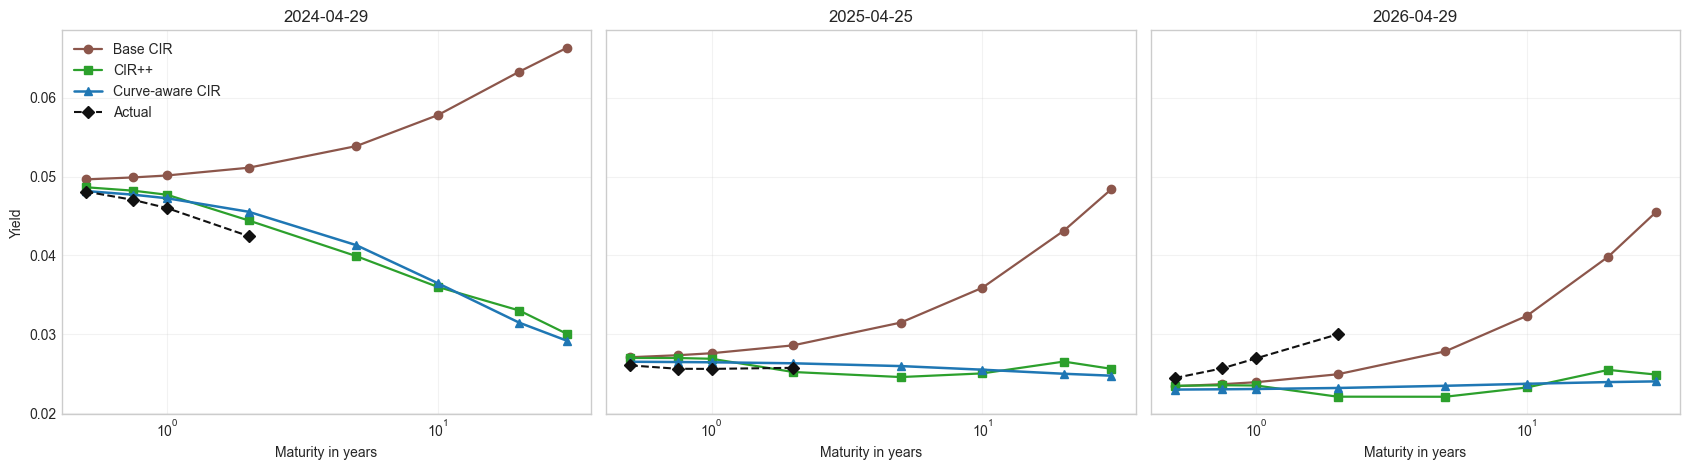

In [12]:
snapshot_rows = [0, len(test_full) // 2, len(test_full) - 1]
target_years = TENOR_YEAR.loc[TARGET_TENORS].to_numpy(float)
actual_tenors = [tenor for tenor in TARGET_TENORS if tenor in test_full.columns]
actual_years = TENOR_YEAR.loc[actual_tenors].to_numpy(float)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, row in zip(axes, snapshot_rows):
    ax.plot(target_years, base_prediction.loc[row, TARGET_TENORS].to_numpy(float), marker="o", linewidth=1.6, label="Base CIR", color="#8c564b")
    ax.plot(target_years, cirpp_prediction.loc[row, TARGET_TENORS].to_numpy(float), marker="s", linewidth=1.6, label="CIR++", color="#2ca02c")
    ax.plot(target_years, best_prediction.loc[row, TARGET_TENORS].to_numpy(float), marker="^", linewidth=1.8, label="Curve-aware CIR", color="#1f77b4")
    ax.plot(actual_years, test_full.loc[row, actual_tenors].to_numpy(float), marker="D", linestyle="--", linewidth=1.5, label="Actual", color="#111111")
    ax.set_xscale("log")
    ax.set_xlabel("Maturity in years")
    ax.set_title(str(pd.to_datetime(test_full.loc[row, "Date"]).date()))
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Yield")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()


## Chosen Model and Files Written

The curve-aware affine CIR model has the best pooled out-of-sample R2. The saved CSVs include every model forecast and the final comparison table.


model,official_pooled_R2
Curve-Aware Affine CIR,0.891358
CIR++ Median Shift,0.884294
Base CIR,0.710957


Selected model: Curve-Aware Affine CIR
Out-of-sample pooled R2: 0.891358
Requirement R2 > 0.85: True


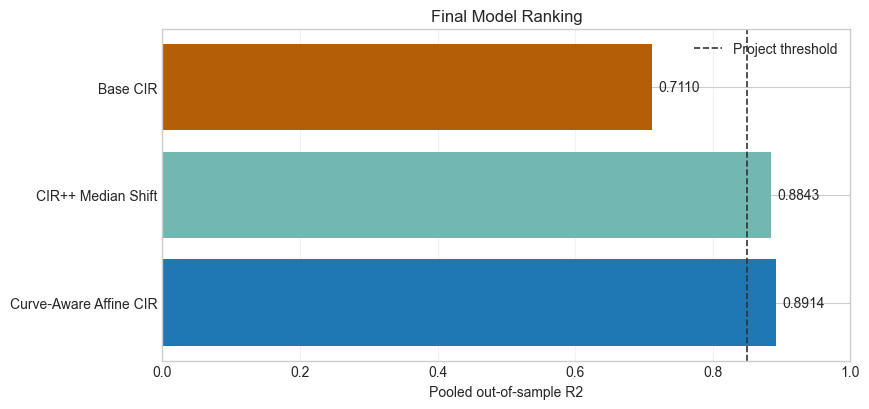

Saved prediction and comparison CSV files in the notebook folder.


In [13]:
model_scores = {
    "Base CIR": base_r2,
    "CIR++ Median Shift": cirpp_r2,
    "Curve-Aware Affine CIR": best_r2,
}
final_comparison = (
    pd.Series(model_scores, name="official_pooled_R2")
    .sort_values(ascending=False)
    .rename_axis("model")
    .reset_index()
)

display(final_comparison.style.format({"official_pooled_R2": "{:.6f}"}).hide(axis="index"))

selected_model = final_comparison.loc[0, "model"]
selected_r2 = float(final_comparison.loc[0, "official_pooled_R2"])
print(f"Selected model: {selected_model}")
print(f"Out-of-sample pooled R2: {selected_r2:.6f}")
print(f"Requirement R2 > {MINIMUM_R2:.2f}: {selected_r2 > MINIMUM_R2}")

fig, ax = plt.subplots(figsize=(8.8, 4.2))
bars = ax.barh(final_comparison["model"], final_comparison["official_pooled_R2"], color=["#1f77b4", "#72b7b2", "#b45f06"])
ax.axvline(MINIMUM_R2, color="#333333", linestyle="--", linewidth=1.2, label="Project threshold")
ax.set_xlim(0, 1.0)
ax.set_xlabel("Pooled out-of-sample R2")
ax.set_title("Final Model Ranking")
ax.legend(frameon=False)
for bar in bars:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{bar.get_width():.4f}", va="center")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

base_prediction.to_csv("base_cir_predictions.csv", index=False)
cirpp_prediction.to_csv("cirplusplus_predictions.csv", index=False)
best_prediction.to_csv("best_cross_sectional_affine_cir_predictions.csv", index=False)
final_comparison.to_csv("final_model_comparison.csv", index=False)

assert selected_r2 > MINIMUM_R2, f"Selected model R2 {selected_r2:.6f} does not exceed {MINIMUM_R2}."
print("Saved prediction and comparison CSV files in the notebook folder.")


## Final Notes

The base CIR model is the clean benchmark. It estimates the short-rate process directly from the 3-month series and then uses the closed-form bond-pricing equations to create the curve. Its main weakness is that the calibration target and the project target are different. The MLE fit cares about the next 3-month rate, while the score cares about the whole curve.

The CIR++ median shift improves the base curve by correcting each maturity with its typical training residual. This is easy to explain and does not use any hidden test information. The limitation is that the shift is fixed. If the slope or curvature regime changes, a fixed historical correction can become stale.

The curve-aware affine CIR extension performs best because it keeps the CIR structure but calibrates with the full reconstruction task in mind. The parameters are not just short-rate MLE parameters anymore; they are chosen to balance short-rate dynamics with curve fit. That tradeoff is reasonable here because the assignment is explicitly about reconstructing the yield curve from the 3-month input.

The Feller condition is reported rather than forced. A negative Feller margin can appear when the data has high short-rate volatility relative to mean reversion and the long-run level. Forcing the condition too strongly can make the curve fit worse, so I use a penalty in the curve-aware model instead of a hard rejection.

The hardest maturities are usually the ones whose movements are less tied to the 3-month rate. Short maturities follow the input more closely, while longer maturities also reflect slope, curvature, and term-premium effects. Since the test input contains only one number per day, no one-factor model can observe those independent curve shocks perfectly.

Overall, the final extension satisfies the required out-of-sample R2 threshold .
